In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Research Question 6: Which Local Authorities consistently outperform or underperform their predicted Attainment 8 score, and is there a geographic pattern among these outliers?

This research question attempts to investigate which Local Authorities over and underperform a predicted Attainment 8 score, based on a linear regression model.

For the purposes of this analysis, the linear regression model will be based on the imd_score, and not the sub-domains, as these all contribute to the overall imd_score, and are likely to introduce substantial multicolinearity. 

LA's are classified as over-performing if their residual (the difference between the actual and predicted attainment8_score) is positive, while they are classified as under-performing if their residual is negative. 

Note that a linear regression model has several assumptions: linearity, normality of residuals, homoscedasticity, and whether residuals are randomly distributed around zero with no clear pattern.



In [24]:
# Importing cleaned dataset
total_dataset = pd.read_csv("/Users/aislinglangston/Desktop/CFG_group_project/data/final_df_total.csv", low_memory=False)

total_dataset.columns

Index(['time_period', 'new_la_code', 'la_name', 'pupil_count',
       'attainment8_average', 'ebacc_aps_average', 'attainment8eng_average',
       'attainment8mat_average', 'attainment8ebacc_average',
       'ebacceng_aps_average', 'ebaccmat_aps_average', 'ebaccsci_aps_average',
       'ebacchum_aps_average', 'ebacclan_aps_average', 'end_year', 'UTLA19CD',
       'UTLA19NM', 'imd_score', 'income_score', 'employment_score',
       'health_score', 'crime_score', 'barriers_score', 'living_env_score',
       'idaci_score', 'children_subdomain'],
      dtype='object')

It is widely acknowledged that grade inflation occured during the years of teacher assessed grades (TAG) during the Covid-19 pandemic. Therefore, in this question, we will consider only examined years.

In [32]:
examined_years = [201819, 202122, 202223, 202324, 202425]

df_examined = total_dataset[
    total_dataset['time_period'].isin(examined_years)
].copy()

# Residuals

We want to look at the residuals to see which LA's are 'overperforming' or 'underperforming'. As this can be different for each year, we consider residuals for each year. 

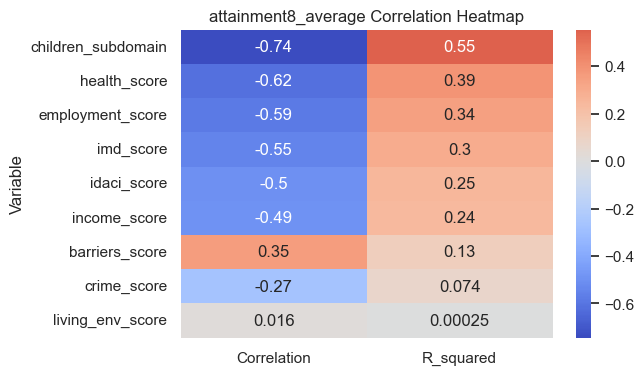

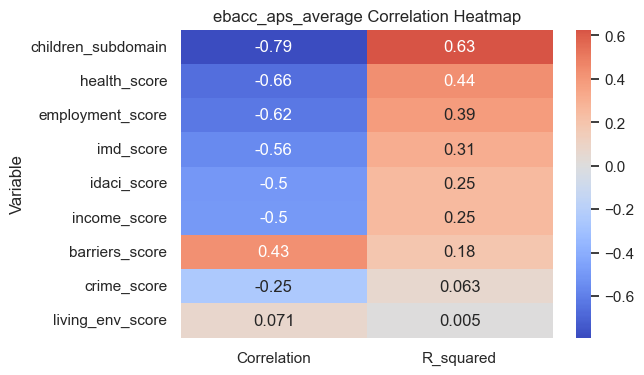

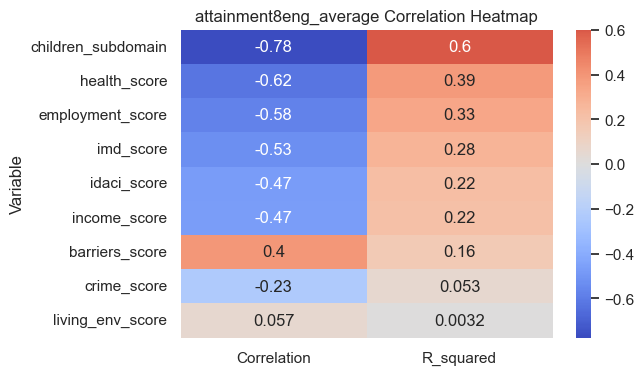

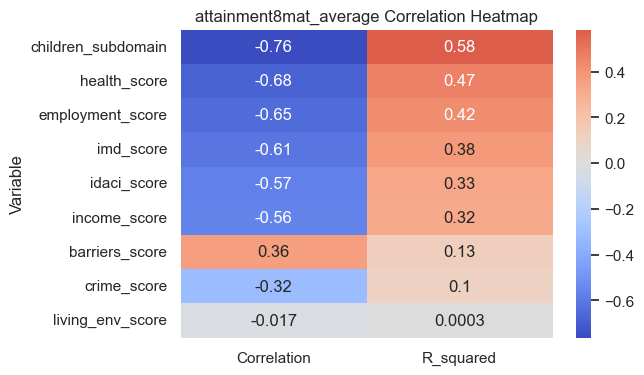

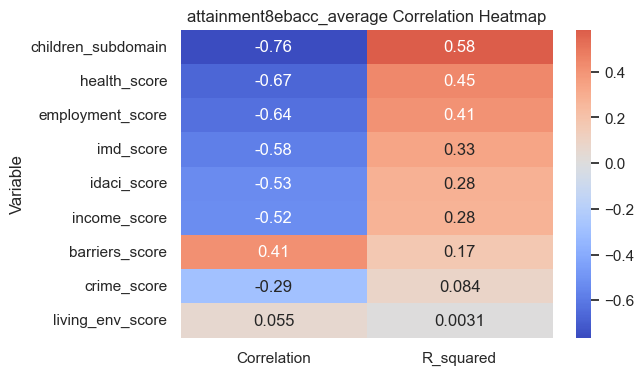

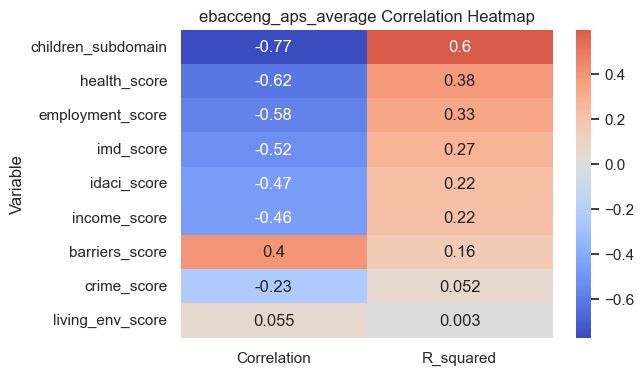

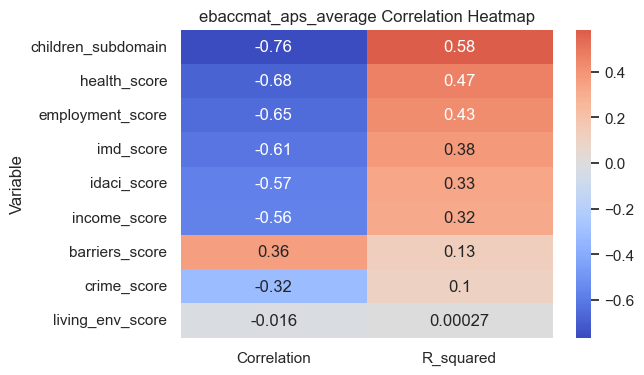

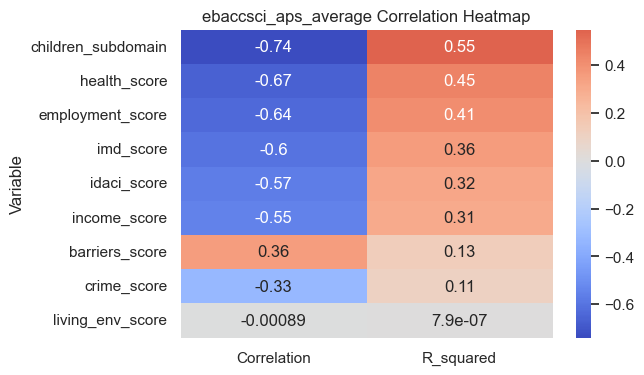

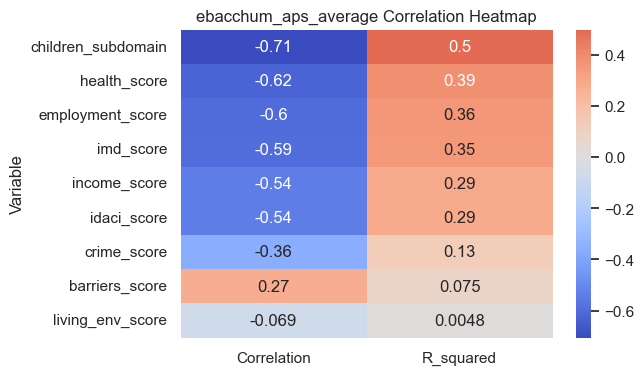

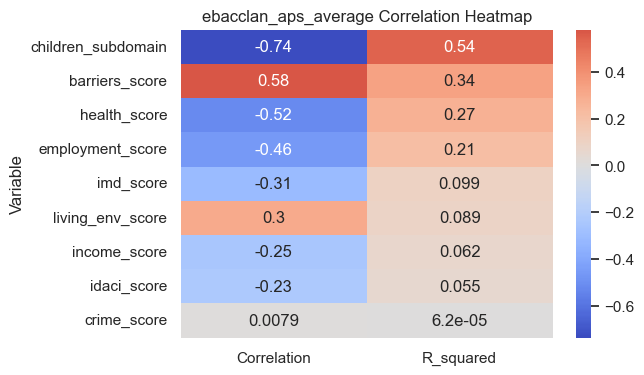

In [31]:
X_columns = [
    'imd_score',
    'income_score',
    'employment_score',
    'health_score',
    'crime_score',
    'barriers_score',
    'living_env_score',
    'idaci_score',
    'children_subdomain'
    ]

y_columns = ['attainment8_average',
             'ebacc_aps_average',
             'attainment8eng_average',
             'attainment8mat_average',
             'attainment8ebacc_average',
             'ebacceng_aps_average',
             'ebaccmat_aps_average',
             'ebaccsci_aps_average',
             'ebacchum_aps_average',
             'ebacclan_aps_average']

for y_col in y_columns:
    correlation_results = []

    for col in X_columns:
        r = total_dataset[col].corr(total_dataset[y_col])

        correlation_results.append({
            'Variable': col,
            'Correlation': r,
            'R_squared': r**2
        })

    correlation_results_df = pd.DataFrame(correlation_results)

    correlation_results_df = correlation_results_df.sort_values(
        'Correlation',
        key=abs,
        ascending=False
    )

    correlation_results_df = correlation_results_df.set_index('Variable')

    plt.figure(figsize=(6,4))
    sns.heatmap(
        correlation_results_df,
        annot=True,
        cmap='coolwarm',
        center=0
    )

    plt.title(f'{y_col} Correlation Heatmap')
    plt.show()

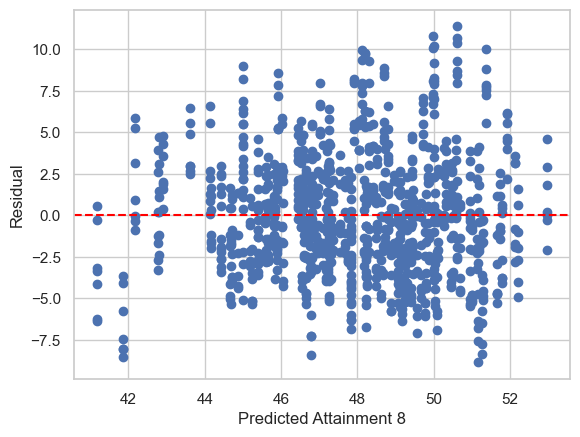

In [11]:
# Residuals
# Fit linear regression of attainment8 on imd_score
# Residuals are positive when a LA 'outperforms, negative when it 'underperforms'

def residuals(df):
    df = df.copy()
    coeffs = np.polyfit(df['imd_score'], df['attainment8_average'], 1)
    slope, intercept = coeffs
    df['predicted_a8'] = intercept + slope * df['imd_score']
    df['residual'] = df['attainment8_average'] - df['predicted_a8']
    
    return df

testing_residuals = residuals(total_dataset)
testing_residuals.head()

plt.scatter(testing_residuals['predicted_a8'],
            testing_residuals['residual'])
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Attainment 8')
plt.ylabel('Residual')
plt.show()

# Research Question 7: Which Local Authorities consistently outperform their predicted Attainment 8 score given their deprivation level, and are there identifiable patterns among these consistent outperformers?

This question aims to support policy makers in identifying, at a LA level, what features or factors might be associated with academic performance when compared with deprivation levels.